In [434]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [435]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [436]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)

In [ ]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [438]:
X.shape

(70000, 784)

In [457]:

neural_net = NeuralNet((28**2, 128, 10), learning_rate=0.0005, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[1].activation_method="softmax"
epochs = 50
losses, y_pred = neural_net.batch_train_optimized(X_train[0:2000], y_train[0:2000], epochs, 1)
print(y_pred)

EPOCH: 0    LOSS: 1.3473019140515203    MOMENTUM: 1.02
EPOCH: 1    LOSS: 0.787707586849011    MOMENTUM: 1.0404
EPOCH: 2    LOSS: 0.6245577039710349    MOMENTUM: 1.061208
EPOCH: 3    LOSS: 0.5449779705905021    MOMENTUM: 1.08243216
EPOCH: 4    LOSS: 0.47880466233297286    MOMENTUM: 1.1040808032
EPOCH: 5    LOSS: 0.46160314727003354    MOMENTUM: 1.126162419264
EPOCH: 6    LOSS: 0.4100209815758576    MOMENTUM: 1.14868566764928
EPOCH: 7    LOSS: 0.4225439247278829    MOMENTUM: 1.1716593810022657
EPOCH: 8    LOSS: 0.39360498420520995    MOMENTUM: 1.195092568622311
EPOCH: 9    LOSS: 0.3865684700573989    MOMENTUM: 1.2189944199947573
EPOCH: 10    LOSS: 0.35817434316290236    MOMENTUM: 1.2433743083946525
EPOCH: 11    LOSS: 0.33992061294855636    MOMENTUM: 1.2682417945625455
EPOCH: 12    LOSS: 0.350989442761277    MOMENTUM: 1.2936066304537963
EPOCH: 13    LOSS: 0.32980624257627755    MOMENTUM: 1.3194787630628724
EPOCH: 14    LOSS: 0.31760643934289307    MOMENTUM: 1.3458683383241299
EPOCH: 15   

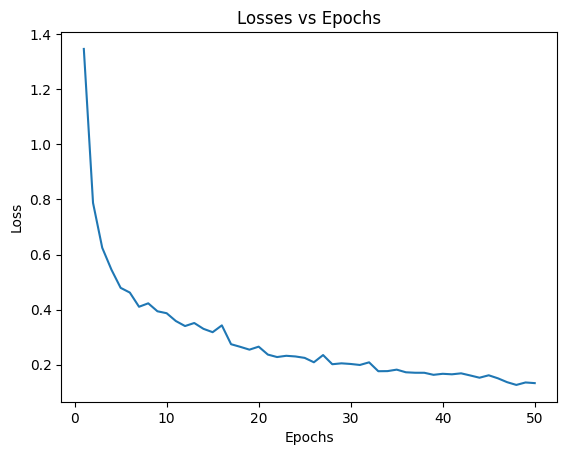

In [458]:
graphics.plot_losses(epochs, losses)

[6 7 3 3 1 6 4 8 1 9]
[6 8 3 5 1 6 4 8 1 4]
Prediction: 6
Prediction: 7
Prediction: 3
Prediction: 3
Prediction: 1
Prediction: 6
Prediction: 4
Prediction: 8
Prediction: 1
Prediction: 9
Prediction: 3
Prediction: 7


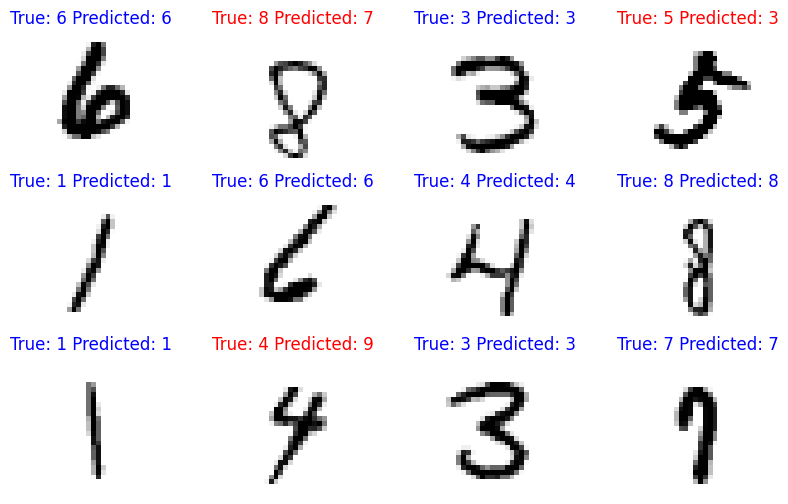

In [459]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
accuracy_score(y_pred, y_test)
print(y_pred.argmax(axis=1)[0:10])
print(y_test.argmax(axis=1)[0:10])

def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 3
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 6))

for i in range(12):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i, y_test.argmax(axis=1)[i], y_pred.argmax(axis=1)[i])
    print(f"Prediction: {y_pred.argmax(axis=1)[i]}")

TypeError: only 0-dimensional arrays can be converted to Python scalars

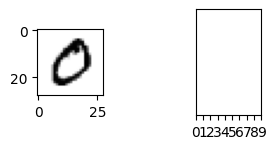

In [460]:
def plot_value_array(i, predictions_array, true_label):
  #true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  #thisplot[true_label].set_color('blue')
w = 8
h = 8
fig = plt.figure(figsize=(8, 8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
    plt.subplot(rows, 2*columns, 2*i)
    plt.imshow(X_image[i], cmap="gray_r")
    #plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(rows, 2*columns, 2*i+2)
    plot_value_array(i, y_pred, y)
plt.show()